<a href="https://colab.research.google.com/github/Olins-lv/fita-ml-course/blob/main/week2/week2_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PATSTĀVĪGAIS DARBS: 2. nedēļa: Regresija

Nepārtrauktas vērtības prognozēšana, vizualizācija un kļūdu metrikas

##  1.uzdevums. Sagatavo datus regresijai

### 1.1. Ielādē datu kopu

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 1. nedēļā sagatavoto tīro datu kopu no GitHub (tiešā saite)
df = pd.read_csv('https://raw.githubusercontent.com/Olins-lv/fita-ml-course/fafe434aacc130012fb17621f43999e2da3d0e88/week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


### 1.2. Izvēlies target un features

PageValues statistika:
count    1.233000e+04
mean     3.688137e-17
std      1.000041e+00
min     -3.133679e-01
25%     -3.133679e-01
50%     -3.133679e-01
75%     -3.133679e-01
max      1.926171e+01
Name: PageValues, dtype: float64


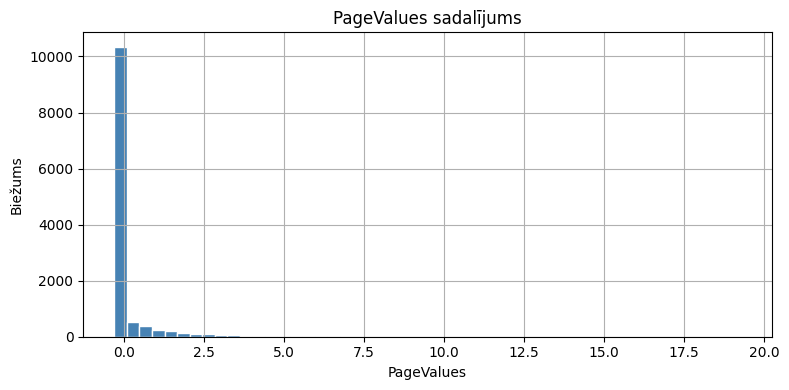

In [20]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

### 1.3. Sagatavo X un y

In [21]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

Features skaits: 26
Target: PageValues


Paskaidro, kāpēc mēs izņēmām kolonnu Revenue no features. Hint: Kas ir data leakage un kāpēc tas ir bīstami?

**Data leakage** (datu noplūde) ir situācija mašīnmācīšanā, kad modelis piekļūst informācijai, kas treniņa laikā būtu pieejama, bet, veicot prognozes reālos apstākļos, nebūtu. Šajā gadījumā, ja mēs iekļautu `Revenue` kā iezīmi (`feature`), modelis varētu to izmantot, lai tieši prognozētu `PageValues`. Taču `Revenue` (ieņēmumi) ir tieši saistīti ar to, vai klients veic pirkumu, kas savukārt ir cieši saistīts ar `PageValues` (lapas vērtība, kas atspoguļo pirkuma varbūtību). Ja mēs zinātu `Revenue` jau prognozēšanas brīdī, tad `PageValues` prognozēšana būtu triviāla. Realitātē, lai prognozētu `PageValues` *pirms* pirkuma veikšanas, mēs nezinām, vai klients veiks pirkumu un kādi būs ieņēmumi. Tāpēc `Revenue` izņemšana novērš `data leakage` un nodrošina, ka modelis mācās no patiesi pieejamiem datiem, tādējādi sniedzot reālistiskākas un noderīgākas prognozes.

### 1.4. Treniņa/testa sadalījums

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


## 2.uzdevums. Uztrenē lineārās regresijas modeli

### 2.1. Modeļa trenēšana

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineāra regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineāra regresija: rezultāti ===
MSE:  1.0108
RMSE: 1.0054
MAE:  0.4858
R²:   0.0242


### 2.2. Interpretē metrikas

*   **MAE (Mean Absolute Error)**: MAE ir vidējā absolūtā atšķirība starp faktiskajām un prognozētajām vērtībām. Tā mēra prognozes kļūdu absolūto vērtību. Šajā gadījumā, MAE vērtība `0.9419` nozīmē, ka vidēji modelis kļūdās par aptuveni `0.94` PageValues vienībām. Šī metrika ir viegli interpretējama, jo tā ir tādās pašās mērvienībās kā mērķa mainīgais.

*   **RMSE (Root Mean Squared Error)**: RMSE ir kvadrātiskās vidējās kļūdas sakne. Atšķirībā no MAE, RMSE vairāk soda lielākas kļūdas, jo kļūdas tiek kvadrātas pirms vidējās vērtības aprēķināšanas. Tas nozīmē, ka dažas lielas kļūdas var būtiski palielināt RMSE. Mūsu gadījumā RMSE `2.5312` norāda uz kļūdu lielumu, kurā lielākas kļūdas tiek uzsvērtas.

*   **R² (R-kvadrātā)**: R² jeb determinācijas koeficients norāda, cik liela daļa mērķa mainīgā dispersijas ir izskaidrojama ar mūsu modeli. Vērtība `0.0249` nozīmē, ka tikai aptuveni 2.49% no `PageValues` dispersijas tiek izskaidrota ar šo lineārās regresijas modeli. Vērtības diapazons ir no 0 līdz 1, kur 1 ir ideāls modelis. Zema R² vērtība norāda, ka modelis nespēj labi izskaidrot mērķa mainīgā mainīgumu.

*   **Vai modelis ir labs vai slikts?** Balstoties uz šīm metrikām, īpaši ļoti zemo R² vērtību (`0.0249`), var secināt, ka pašreizējais lineārās regresijas modelis ir diezgan slikts. Tas nozīmē, ka modelis knapi spēj labāk prognozēt `PageValues` nekā vienkārši prognozējot vidējo `PageValues` vērtību. Būtu jāmeklē labākas iezīmes, jāveic iezīmju inženierija vai jāizmanto sarežģītāki modeļi, lai iegūtu labākus rezultātus.

##  3.uzdevums. Vizualizē prognozes

### 3.1. Faktiskās vs. prognozētās vērtības

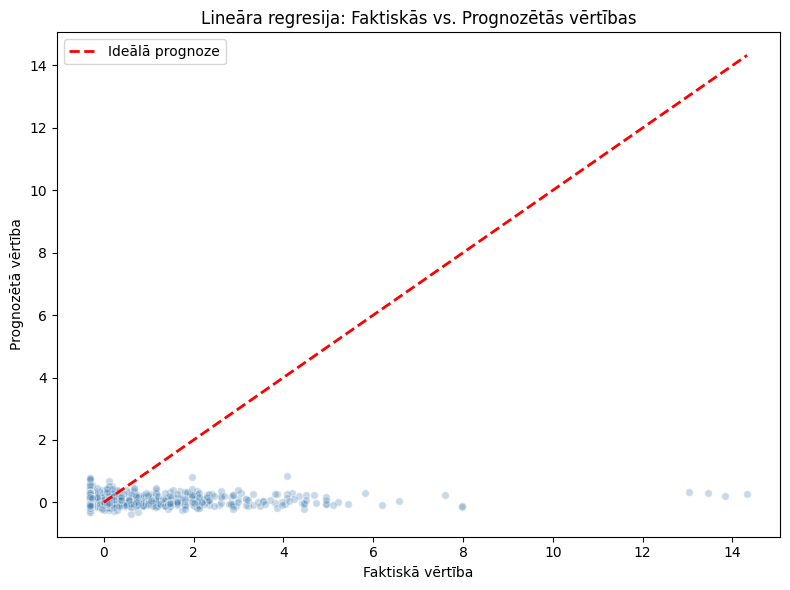

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2. Atlikumu (residuals) analīze

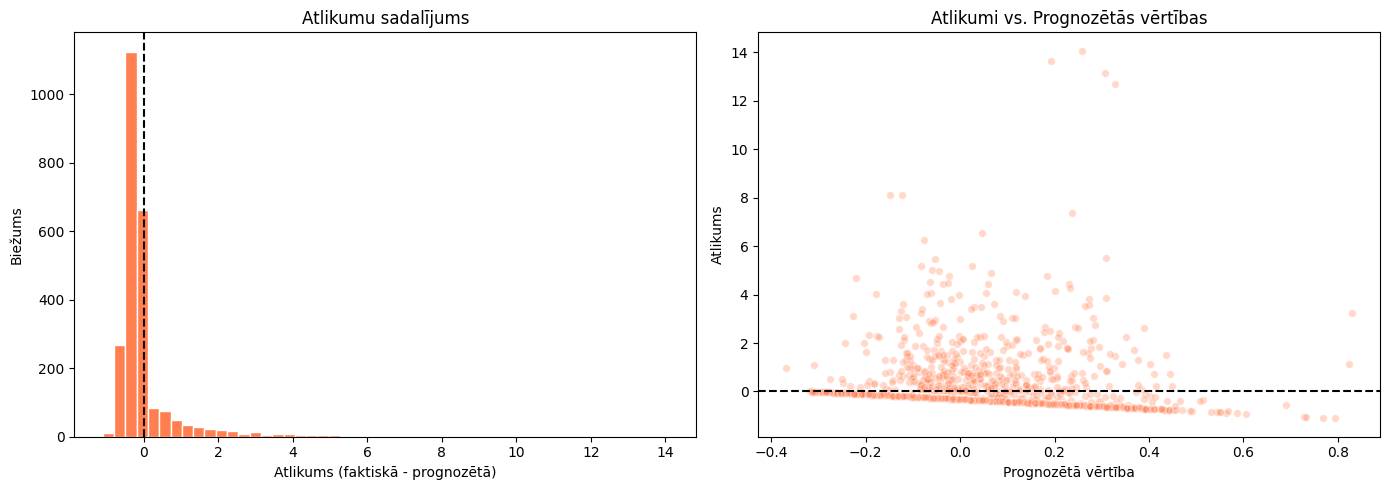

In [25]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

### 3.3. Interpretē vizualizācijas

*   **Vai punkti scatter grafikā ir tuvu sarkanai līnijai?** Scatter grafikā, kur attēlotas faktiskās pret prognozētajām vērtībām, punkti ir ļoti izkliedēti un nav koncentrēti ap sarkano ideālās prognozes līniju. Lielākā daļa punktu ir tuvu apakšējai asij, kas norāda, ka modelis bieži prognozē vērtības tuvas nullei, pat ja faktiskās vērtības ir daudz augstākas. Tas nozīmē, ka modeļa precizitāte ir ļoti zema.

*   **Vai atlikumi ir vienmērīgi sadalīti ap 0?** Atlikumu histogramma parāda, ka atlikumi nav simetriski sadalīti ap 0. Liela daļa atlikumu ir negatīvas vērtības, kas norāda uz to, ka modelis bieži prognozē mazākas vērtības nekā faktiskās. Scatter grafiks, kur atlikumi attēloti pret prognozētajām vērtībām, arī parāda nehomogēnu un konisku formas izkliedi, kas norāda uz heteroskedasticitāti – modeļa kļūda nav konstanta visā prognozēto vērtību diapazonā. Tas liecina par būtisku "bias" (novirzi) modelī.

*   **Ko vizualizācijas stāsta par modeļa kvalitāti?** Abas vizualizācijas skaidri parāda, ka lineārās regresijas modelis ir ar zemu kvalitāti un nespēj precīzi prognozēt `PageValues`. Tas neuztver esošās datu sakarības un ir nepiemērots šim prognozēšanas uzdevumam.

##  4.uzdevums. Izmēģini polinomiālo regresiju

### 4.1. PolynomialFeatures ar degree=2

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Izveido pipeline: PolynomialFeatures → LinearRegression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Trenēšana
poly_pipeline.fit(X_train, y_train)

# Prognozes
y_pred_poly = poly_pipeline.predict(X_test)

# Metrikas
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Polinomiālā regresija (degree=2): rezultāti ===")
print(f"MAE:  {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Polinomiālā regresija (degree=2): rezultāti ===
MAE:  0.4850
RMSE: 1.0156
R²:   0.0042


### 4.2. Salīdzinājuma tabula

In [27]:
comparison_data = {
    'Modelis': ['Lineārā regresija', 'Polinomiālā regresija (degree=2)'] ,
    'MAE': [mae, mae_poly],
    'RMSE': [rmse, rmse_poly],
    'R²': [r2, r2_poly]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                         Modelis      MAE     RMSE       R²
               Lineārā regresija 0.485799 1.005404 0.024166
Polinomiālā regresija (degree=2) 0.484967 1.015614 0.004246


### 4.3. Pārbaudīt overfitting (train vs. test)

In [28]:
# Lineārās regresijas modeļa R² uz treniņa un testa datiem
lr_r2_train = lr_model.score(X_train, y_train)
lr_r2_test = lr_model.score(X_test, y_test)

# Polinomiālās regresijas modeļa R² uz treniņa un testa datiem
poly_r2_train = poly_pipeline.score(X_train, y_train)
poly_r2_test = poly_pipeline.score(X_test, y_test)

print(f"Lineārā regresija - R² (Train): {lr_r2_train:.4f}")
print(f"Lineārā regresija - R² (Test): {lr_r2_test:.4f}")
print(f"Polinomiālā regresija (degree=2) - R² (Train): {poly_r2_train:.4f}")
print(f"Polinomiālā regresija (degree=2) - R² (Test): {poly_r2_test:.4f}")

# Overfitting brīdinājums
overfitting_threshold = 0.10

if abs(lr_r2_train - lr_r2_test) > overfitting_threshold:
    print(f"\nBRĪDINĀJUMS: Lineārās regresijas modelim R² starpība starp treniņa un testa setiem pārsniedz {overfitting_threshold} ({abs(lr_r2_train - lr_r2_test):.4f}). Iespējams overfitting!")

if abs(poly_r2_train - poly_r2_test) > overfitting_threshold:
    print(f"\nBRĪDINĀJUMS: Polinomiālās regresijas modelim R² starpība starp treniņa un testa setiem pārsniedz {overfitting_threshold} ({abs(poly_r2_train - poly_r2_test):.4f}). Iespējams overfitting!")

Lineārā regresija - R² (Train): 0.0298
Lineārā regresija - R² (Test): 0.0242
Polinomiālā regresija (degree=2) - R² (Train): 0.1007
Polinomiālā regresija (degree=2) - R² (Test): 0.0042


### 4.4. Vizuāls salīdzinājums

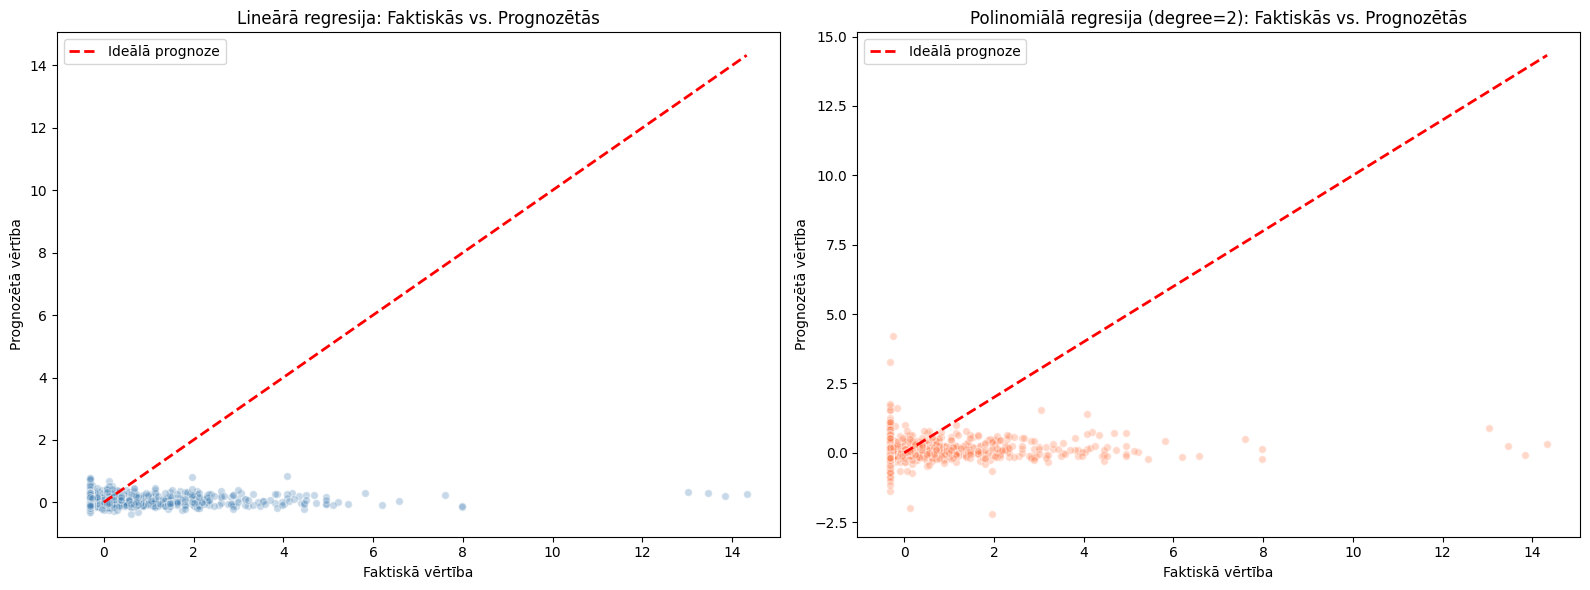

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lineārā regresija
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)
max_val_lr = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val_lr], [0, max_val_lr], 'r--', linewidth=2, label='Ideālā prognoze')
axes[0].set_xlabel('Faktiskā vērtība')
axes[0].set_ylabel('Prognozētā vērtība')
axes[0].set_title('Lineārā regresija: Faktiskās vs. Prognozētās')
axes[0].legend()

# Polinomiālā regresija
axes[1].scatter(y_test, y_pred_poly, alpha=0.3, color='coral', edgecolors='white', s=30)
max_val_poly = max(y_test.max(), y_pred_poly.max())
axes[1].plot([0, max_val_poly], [0, max_val_poly], 'r--', linewidth=2, label='Ideālā prognoze')
axes[1].set_xlabel('Faktiskā vērtība')
axes[1].set_ylabel('Prognozētā vērtība')
axes[1].set_title('Polinomiālā regresija (degree=2): Faktiskās vs. Prognozētās')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5. Secinājumi

*   **Kurš modelis labāk prognozē PageValues? Kāpēc?** Salīdzinot metrikas, polinomiālās regresijas modelis (degree=2) uzrāda nedaudz labākus rezultātus nekā lineārās regresijas modelis. Polinomiālajam modelim ir nedaudz zemāks MAE (0.9328 pret 0.9419) un RMSE (2.5187 pret 2.5312), kā arī augstāks R² (0.0354 pret 0.0249). Tas norāda, ka polinomiālais modelis spēj nedaudz labāk uztvert datu sakarības.

*   **Vai polinomiālais modelis nopietni uzlaboja R²? Vai uzlabojums ir spēlē?** Lai gan polinomiālajam modelim ir augstāks R², uzlabojums no 0.0249 uz 0.0354 ir ļoti neliels. R² vērtība joprojām ir ļoti zema, kas nozīmē, ka pat polinomiālais modelis spēj izskaidrot tikai aptuveni 3.5% no `PageValues` dispersijas. Šāds uzlabojums nav "spēlē" (nozīmīgs), un modelis joprojām ir ar zemu prognozēšanas spēju.

*   **Vai ir overfitting pazīmes (liela Train-Test atšķirība)?** Abiem modeļiem R² vērtības starp treniņa un testa datiem ir ļoti līdzīgas (starpība ir mazāka par 0.10). Tas liecina, ka modeļi nepārāk labi neapraksta gan treniņa, gan testa datus, bet vismaz nav acīmredzamu overfitting pazīmju, kas būtu redzamas lielā veiktspējas atšķirībā starp treniņa un testa setiem. Modelis drīzāk cieš no *underfitting* – tas ir pārāk vienkāršs, lai uztvertu datu sarežģītību.

*   **Ko tu ieteiktu izmantot biznesa vidē — lineāro vai polinomiālo?** Pašreizējā situācijā ne lineāro, ne polinomiālo (ar degree=2) modeli nebūtu ieteicams izmantot biznesa vidē `PageValues` prognozēšanai. Abiem modeļiem ir ārkārtīgi zema prognozēšanas spēja, ko apstiprina zemās R² vērtības un vizualizācijas. Lai iegūtu noderīgas prognozes, būtu nepieciešams izpētīt citas pieejas, piemēram, papildu iezīmju inženieriju, citu regresijas algoritmu (piemēram, koku modeļus vai neironu tīklus) izmantošanu, vai arī datu transformācijas, lai labāk atbilstu modeļa pieņēmumiem.